In [2]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset

class GenreDataset(Dataset):
    def __init__(self, data_dir, label_map,train=False):
        self.data_dir = data_dir
        self.files = os.listdir(data_dir)
        self.label_map = label_map
        self.train = train

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        file_path = os.path.join(self.data_dir, file_name)

        # Load spectrogram
        mel = np.load(file_path)

        # Convert to tensor
        mel = torch.tensor(mel, dtype=torch.float32)

        # Add channel dimension
        mel = mel.unsqueeze(0)
        mel = mel.repeat(3,1,1)
        mel = (mel - mel.mean()) / mel.std()
        # Extract label from filename
        genre = file_name.split("_")[0]
        label = self.label_map[genre]

        return mel, label

In [3]:
genres = sorted(os.listdir("D:\\Music_Gener_Classification\\Data\\genres_original"))
label_map = {genre: i for i, genre in enumerate(genres)}

print(label_map)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [12]:
from torch.utils.data import DataLoader


train_dataset = GenreDataset("processed_data/train", label_map)
val_dataset = GenreDataset("processed_data/val", label_map)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [15]:
train_loader.batch_size

32

In [8]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

# change last layer for 10 genres
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

print(device)

d:\Music_Gener_Classification\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Music_Gener_Classification\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


cuda


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [19]:
epochs = 20
best_acc = 0

for epoch in range(epochs):

    # ----- TRAINING -----
    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = 100 * train_correct / train_total


    # ----- VALIDATION -----
    model.eval()

    val_correct = 0
    val_total = 0
    val_loss = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_resnet18.pth")


    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} "
          f"Val Acc: {val_acc:.2f}%")

Epoch [1/20] Train Loss: 231.5161 Train Acc: 81.89% Val Loss: 57.4776 Val Acc: 81.51%
Epoch [2/20] Train Loss: 41.2664 Train Acc: 97.23% Val Loss: 69.7209 Val Acc: 79.16%
Epoch [3/20] Train Loss: 20.3895 Train Acc: 98.62% Val Loss: 60.8957 Val Acc: 81.09%
Epoch [4/20] Train Loss: 16.2657 Train Acc: 98.76% Val Loss: 76.9565 Val Acc: 80.21%
Epoch [5/20] Train Loss: 13.1491 Train Acc: 98.89% Val Loss: 77.8519 Val Acc: 80.32%
Epoch [6/20] Train Loss: 14.3789 Train Acc: 98.84% Val Loss: 77.2143 Val Acc: 81.75%
Epoch [7/20] Train Loss: 12.3631 Train Acc: 99.03% Val Loss: 72.0412 Val Acc: 81.86%
Epoch [8/20] Train Loss: 13.0699 Train Acc: 98.92% Val Loss: 88.6654 Val Acc: 80.04%
Epoch [9/20] Train Loss: 14.8105 Train Acc: 98.79% Val Loss: 84.3239 Val Acc: 80.63%
Epoch [10/20] Train Loss: 8.4462 Train Acc: 99.25% Val Loss: 87.8326 Val Acc: 81.65%
Epoch [11/20] Train Loss: 5.3698 Train Acc: 99.50% Val Loss: 77.4353 Val Acc: 82.18%
Epoch [12/20] Train Loss: 3.6697 Train Acc: 99.69% Val Loss: 72.

In [20]:
torch.save(model.state_dict(), "resnet18_20_ep.pth")

In [5]:
from torch.utils.data import DataLoader

test_dataset = GenreDataset("D:\\Music_Gener_Classification\\processed_data\\test",label_map)

test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

In [10]:
import numpy as np
y_true = []
y_pred = []

model.load_state_dict(torch.load("best_resnet18.pth"))

model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total

print("Test Accuracy:", test_acc)

C:\Users\Renish\AppData\Local\Temp\ipykernel_2884\3165171074.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_resnet18.pth"))


Test Accuracy: 82.16918216918216


In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[254   0   4   4   0   1   1   0   5  16]
 [  0 280   0   0   0   2   0   0   2   0]
 [  4   0 230   6   0  16   0   0   3  26]
 [  1  11  10 168  27   1   5  47  14   1]
 [  3   0   0  16 217   7  24  13   2   3]
 [  0   0   8   0   0 277   0   0   0   0]
 [  6   0   0   2   0   0 260   0   0  17]
 [  0   0  17   2   0   0   0 252  12   2]
 [  6  10   4   9   0  16   3   3 219  15]
 [  8   2  32   3   0   9   7  35   5 184]]


In [15]:
import pandas as pd 

genres = [
    "blues","classical","country","disco","hiphop",
    "jazz","metal","pop","reggae","rock"
]


cm_table = pd.DataFrame(cm, index=genres, columns=genres)

display(cm_table)

,blues,classical,country,disco,hiphop,jazz,metal,pop,reggae,rock
blues,254,0,4,4,0,1,1,0,5,16
classical,0,280,0,0,0,2,0,0,2,0
country,4,0,230,6,0,16,0,0,3,26
disco,1,11,10,168,27,1,5,47,14,1
hiphop,3,0,0,16,217,7,24,13,2,3
jazz,0,0,8,0,0,277,0,0,0,0
metal,6,0,0,2,0,0,260,0,0,17
pop,0,0,17,2,0,0,0,252,12,2
reggae,6,10,4,9,0,16,3,3,219,15
rock,8,2,32,3,0,9,7,35,5,184


<h4>Graphs</h4>

In [11]:
import matplotlib.pyplot as plt

epochs = list(range(1,21))

train_acc = [
81.89,97.23,98.62,98.76,98.89,98.84,99.03,98.92,98.79,99.25,
99.50,99.69,99.00,99.25,98.97,99.04,99.58,99.64,99.66,99.01
]

val_acc = [
81.51,79.16,81.09,80.21,80.32,81.75,81.86,80.04,80.63,81.65,
82.18,83.58,83.02,79.93,79.37,79.89,83.30,83.65,79.89,81.79
]

train_loss = [
231.5161,41.2664,20.3895,16.2657,13.1491,14.3789,12.3631,13.0699,14.8105,8.4462,
5.3698,3.6697,11.5362,8.5250,11.8433,11.7848,4.6621,3.7021,4.1211,11.4357
]

val_loss = [
57.4776,69.7209,60.8957,76.9565,77.8519,77.2143,72.0412,88.6654,84.3239,87.8326,
77.4353,72.5450,74.7812,87.0477,98.8124,90.9032,75.5944,72.2040,98.3255,91.6479
]

<h4>Accuracy Graph</h4>

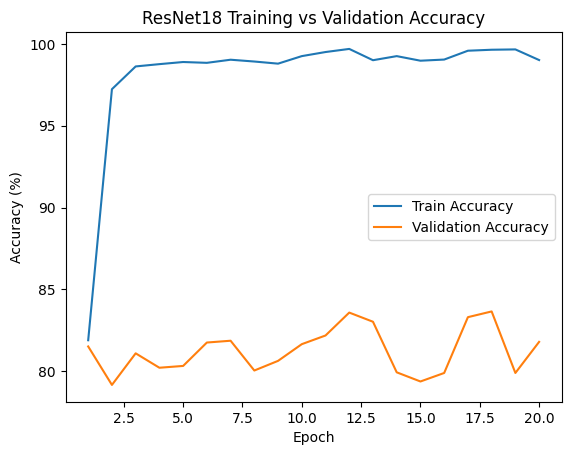

In [12]:
plt.figure()

plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 Training vs Validation Accuracy")
plt.legend()

plt.show()

<h4>Loss Graph</h4>

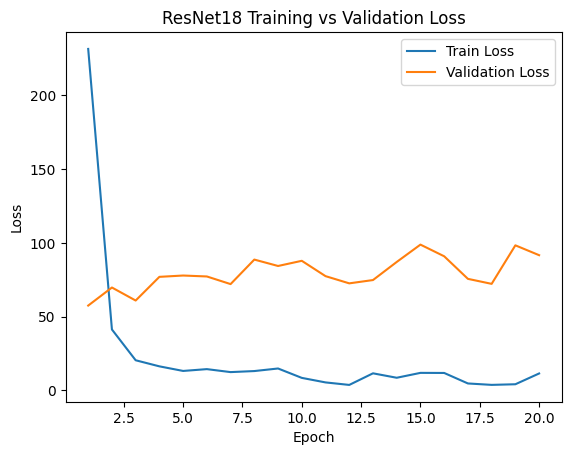

In [13]:
plt.figure()

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Training vs Validation Loss")
plt.legend()

plt.show()